# Adición de las variables para el calculo de calor a los archivos de tendencias
***
Created: 01/05/2026             updated: ---

La idea de este código es crear un dataset final que se guardará en un archivo netCDF en ./Data/heat_flux/ que contenga todas las variables necesarias para calcular el flujo de calor por cuencas. La idea es partir del archivo de tendencias por niveles, que tiene dimensiones de latitud, longitud y presión y los datos totales de temperatura, salinidad, densidad, y calor especifico, de forma que para cada punto y presión hay un valor de tendencia, calor específico y densidad

In [1]:
# Packages for data manipulation
import numpy as np
import xarray as xr
import pandas as pd
import datetime as dt

# Packages for visualization
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Package for progress bar
from tqdm import tqdm

# Package for file handling
import os

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Características previas

In [2]:
grid_resolution = 0.25
min_press = 4000
max_press = None
start_year = 1990
end_year = 2010
press_step = 20
code_press =str(min_press)[0] + 'k'
grid_code = str(grid_resolution).split('.')[-1]
robust = True

### Abrimos ficheros

In [3]:
ds = xr.open_dataset('./Data/join/total_filt.nc')
if robust:
    ds_tendency = xr.open_dataset(f'./Data/tendency_levels/tendency_levels_{start_year}_{end_year}_{grid_code}_{code_press}_robust.nc')
else :
    ds_tendency = xr.open_dataset(f'./Data/tendency_levels/tendency_levels_{start_year}_{end_year}_{grid_code}_{code_press}.nc')
grid = xr.open_dataset(f'./Data/grid/occupation_grid_{grid_code}.nc')

In [ ]:
ds

In [ ]:
ds_tendency

In [ ]:
grid

Recortamos ds y el grid para que solo tengan las fechas y valores que necesitamos

In [4]:
# Cutting the dataset to have data from the wanted years
grid = grid.where((grid.times.dt.year >= start_year) & (grid.times.dt.year <= end_year), drop = True)

# Cutting the dataset to have data from exact pressure
if max_press is not None:
    ds = ds.where((ds.pressure <= max_press) & (ds.pressure >= min_press), drop=True)

else:
    ds = ds.where(ds.pressure >= min_press, drop=True)

### Adición de las variables al dataset de tendencias

In [5]:
# Function that given the grid, the tendency and the data return the dataset with all the variables
def add_variables(ds, ds_tendency, grid):
    # Extract the values of variables
    latitudes = grid.latitude.values
    longitudes = grid.longitude.values
    profiles = grid.profiles.values
    n = grid.n.values
    tendency_press = ds_tendency.pressure.values

    # Create a matrix of cp and density with the same dimensions than the grid
    density = np.full((len(latitudes), len(longitudes), len(tendency_press)), np.nan)
    cp = np.full((len(latitudes), len(longitudes), len(tendency_press)), np.nan)

    # Precalculate the valid pixels
    valid_idx = []
    for i in range(len(latitudes)):
        for j in range(len(longitudes)):
            # Check if there are profiles
            if not np.isnan(n[i, j]):
                # Obtaining index of profiles with Nans
                profs = profiles[i, j, :] 
                profs = profs[~np.isnan(profs)].astype(int)

                valid_idx.append((i, j, profs))

    # Explore every pressure level
    for k in range(1, len(tendency_press)):
        # Cut the matrix by press
        ds_levels = ds.where((ds.pressure <= tendency_press[k]) & (ds.pressure >= tendency_press[k-1]), drop = True)

        # Calculate the mean for all the profiles
        density_mean_prof = ds_levels.ctd_density_filt.mean('P').values
        cp_mean_prof = ds_levels.ctd_cp_filt.mean('P').values

        # Explote the pixels where there ir profiles
        for i, j, profs in valid_idx:
            # Extract the mean
            density_mean = density_mean_prof[profs]
            cp_mean = cp_mean_prof[profs]

            # Delete nans
            valid_density = ~np.isnan(density_mean)
            density_mean = density_mean[valid_density]

            valid_cp = ~np.isnan(cp_mean)
            cp_mean = cp_mean[valid_cp]

            # Save the mean values extracted
            cp[i, j, k] = np.mean(cp_mean)
            density[i, j, k] = np.mean(density_mean)

    # Add the variables to ds_tendency
    ds_tendency['density'] = (['latitude', 'longitude', 'pressure'],density)
    ds_tendency['Cp'] = (['latitude', 'longitude', 'pressure'], cp)
    ds_tendency['mask'] = (['latitude', 'longitude'],grid.mask.values)  
    ds_tendency['basin'] =(['latitude', 'longitude'],grid.basin.values)  
    ds_tendency['batimetry'] = (['latitude', 'longitude'],grid.batimetry.values)  
    ds_tendency['surface'] = (['latitude', 'longitude'],grid.surface.values)  

    # Add atributtes
    ds_tendency['Cp'].attrs['units'] = 'J/(kg C)'
    ds_tendency['Cp'].attrs['standard_name'] = 'sea_water_specific_heat_capacity'

    ds_tendency['density'].attrs['units'] = 'kg/m^3'
    ds_tendency['density'].attrs['standard_name'] = 'sea_water_density'

    # Set coordinates
    ds_tendency = ds_tendency.set_coords(['mask', 'basin', 'batimetry', 'surface'])  

    # return de dataset
    return ds_tendency            


Aplicamos

In [6]:
ds_heat_vars = add_variables(ds, ds_tendency, grid)
ds_heat_vars

<xarray.Dataset> Size: 2GB
Dimensions:    (latitude: 556, longitude: 1309, pressure: 125)
Coordinates:
  * latitude   (latitude) float64 4kB -76.75 -76.5 -76.0 ... 62.75 63.0 63.25
  * longitude  (longitude) float64 10kB -180.0 -179.8 -179.5 ... 179.8 180.0
    mask       (latitude, longitude) float64 6MB 10.0 10.0 10.0 ... nan nan nan
    basin      (latitude, longitude) <U18 52MB 'SPEastAntartica' ... ''
    batimetry  (latitude, longitude) float64 6MB nan -635.3 ... -42.65 nan
    surface    (latitude, longitude) float64 6MB 1.771e+08 ... 3.478e+08
  * pressure   (pressure) int64 1kB 4000 4020 4040 4060 ... 6420 6440 6460 6480
Data variables:
    tendency   (latitude, longitude, pressure) float64 728MB ...
    density    (latitude, longitude, pressure) float64 728MB nan nan ... nan nan
    Cp         (latitude, longitude, pressure) float64 728MB nan nan ... nan nan
Attributes:
    description:  Dataset of temperature tendencies by pressure levels betwee...

### Revisar las distribuciones de valores de las variables calculadas importantes

(0.0, 10.0)

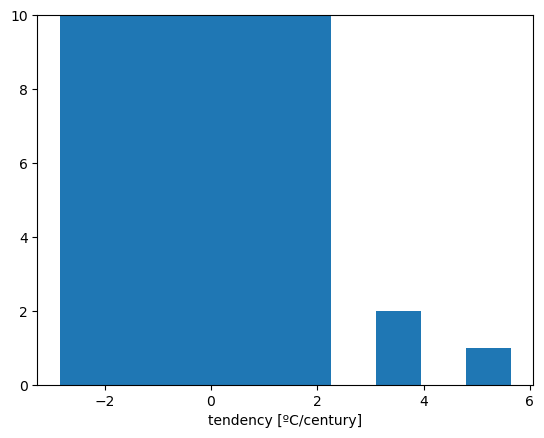

In [7]:
ds_heat_vars.tendency.plot.hist()
plt.ylim(0,10)

In [ ]:
ds_heat_vars.Cp.plot.hist()

In [ ]:
ds_heat_vars.density.plot.hist()

### Guardamos el dataset

In [8]:
if robust:
    ds_heat_vars.to_netcdf(f'./Data/Heat_vars/Heat_vars_{start_year}_{end_year}_{str(grid_resolution).split('.')[-1]}_{code_press}_robust.nc')
else:
    ds_heat_vars.to_netcdf(f'./Data/Heat_vars/Heat_vars_{start_year}_{end_year}_{str(grid_resolution).split('.')[-1]}_{code_press}.nc')

### Cerramos todos los dataset

In [ ]:
ds.close()
ds_tendency.close()
grid.close()
ds_heat_vars.close()

: 